## Imports & config

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset

ROOT = Path.cwd()
if not (ROOT / "final_data").exists() and (ROOT.parent / "final_data").exists():
    ROOT = ROOT.parent

FINAL_DATA_DIR = ROOT / "final_data"
SPLIT_FOLDERS = {
    "train": "train",
    "val": "validate",
    "test": "test",
}
SPLIT_CSVS = {
    "train": ROOT / "train.csv",
    "val": ROOT / "val.csv",
    "test": ROOT / "test.csv",
}

LABELS = [
    "No gesture",
    "Swiping Down",
    "Swiping Left",
    "Swiping Right",
    "Swiping Up",
    "Turning Hand Clockwise",
    "Turning Hand Counterclockwise",
    "Zooming In With Two Fingers",
    "Zooming Out With Two Fingers",
]
LABEL_TO_IDX = {label: idx for idx, label in enumerate(LABELS)}
IDX_TO_LABEL = {idx: label for label, idx in LABEL_TO_IDX.items()}

NUM_FRAMES = 37
INPUT_SIZE = 63
NUM_CLASSES = len(LABELS)
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.3
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 7
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


## Dataset

In [2]:
class GestureDataset(Dataset):
    def __init__(self, split):
        folder = SPLIT_FOLDERS[split]
        data_dir = FINAL_DATA_DIR / folder
        metadata = pd.read_csv(SPLIT_CSVS[split])

        self.samples = []
        for _, row in metadata.iterrows():
            video_id = int(row["video_id"])
            npy_path = data_dir / f"{video_id}.npy"
            if not npy_path.exists():
                continue
            self.samples.append(
                (npy_path, LABEL_TO_IDX[row["label"]])
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        npy_path, label = self.samples[idx]
        seq = np.load(npy_path).astype(np.float32)
        return torch.from_numpy(seq), torch.tensor(label, dtype=torch.long)


train_dataset = GestureDataset("train")
val_dataset = GestureDataset("val")
test_dataset = GestureDataset("test")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

Train: 17605
Val:   2218
Test:  2197


## RNN model

In [3]:
class GestureRNN(nn.Module):
    def __init__(
        self,
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT,
    ):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        _, hidden = self.rnn(x)
        last_hidden = hidden[-1]
        logits = self.classifier(self.dropout(last_hidden))
        return logits


model = GestureRNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")
print(model)

Trainable parameters: 58,889
GestureRNN(
  (rnn): RNN(63, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=9, bias=True)
)


## Training (early stopping on validation loss)

In [4]:
def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for sequences, labels in loader:
        sequences = sequences.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        logits = model(sequences)
        loss = criterion(logits, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(
        train_loader, model, criterion, optimizer
    )
    val_loss, val_acc = run_epoch(val_loader, model, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
model.to(device)
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 01 | train loss 1.7642 acc 0.3940 | val loss 1.5426 acc 0.4748
Epoch 02 | train loss 1.6327 acc 0.4464 | val loss 1.6427 acc 0.4130
Epoch 03 | train loss 1.7996 acc 0.3784 | val loss 1.8056 acc 0.3769
Epoch 04 | train loss 1.6481 acc 0.4328 | val loss 1.4785 acc 0.4950
Epoch 05 | train loss 1.5776 acc 0.4687 | val loss 1.6273 acc 0.4689
Epoch 06 | train loss 1.4603 acc 0.5083 | val loss 1.3676 acc 0.5473
Epoch 07 | train loss 1.5007 acc 0.4956 | val loss 1.5325 acc 0.4653
Epoch 08 | train loss 1.3519 acc 0.5402 | val loss 1.8849 acc 0.3774
Epoch 09 | train loss 1.6623 acc 0.4495 | val loss 1.9908 acc 0.3530
Epoch 10 | train loss 1.7962 acc 0.3777 | val loss 1.6421 acc 0.4202
Epoch 11 | train loss 1.6673 acc 0.4226 | val loss 1.8358 acc 0.3548
Epoch 12 | train loss 1.6931 acc 0.4170 | val loss 1.9426 acc 0.4107
Epoch 13 | train loss 1.7259 acc 0.4164 | val loss 1.9516 acc 0.3476
Early stopping at epoch 13
Best validation loss: 1.3676


## Training curves

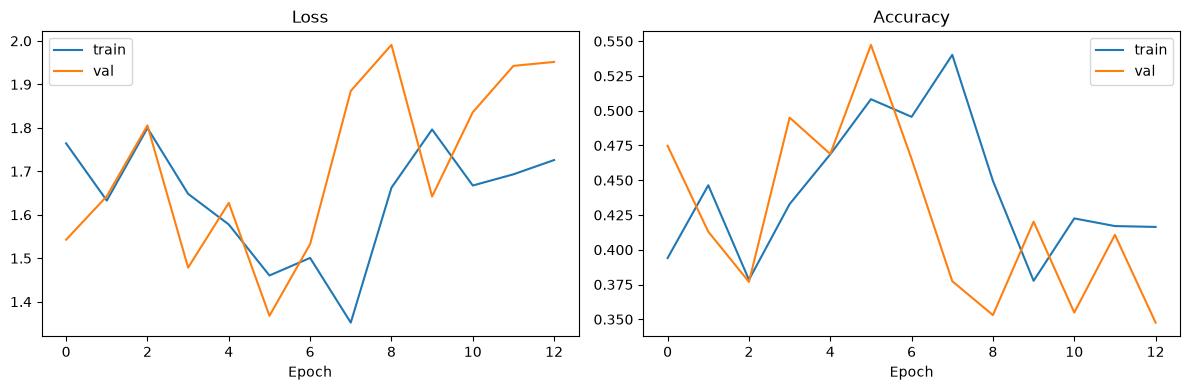

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## Test evaluation

Test loss: 1.3881
Test accuracy: 0.5371

Classification report:
                               precision    recall  f1-score   support

                   No gesture     0.6226    0.8971    0.7350       719
                 Swiping Down     0.4226    0.5628    0.4828       199
                 Swiping Left     0.4754    0.3169    0.3803       183
                Swiping Right     0.2500    0.0169    0.0317       177
                   Swiping Up     0.5026    0.5104    0.5065       192
       Turning Hand Clockwise     0.8056    0.3791    0.5156       153
Turning Hand Counterclockwise     0.6939    0.2166    0.3301       157
  Zooming In With Two Fingers     0.4632    0.2136    0.2924       206
 Zooming Out With Two Fingers     0.3647    0.6066    0.4555       211

                     accuracy                         0.5371      2197
                    macro avg     0.5112    0.4133    0.4144      2197
                 weighted avg     0.5298    0.5371    0.4934      2197



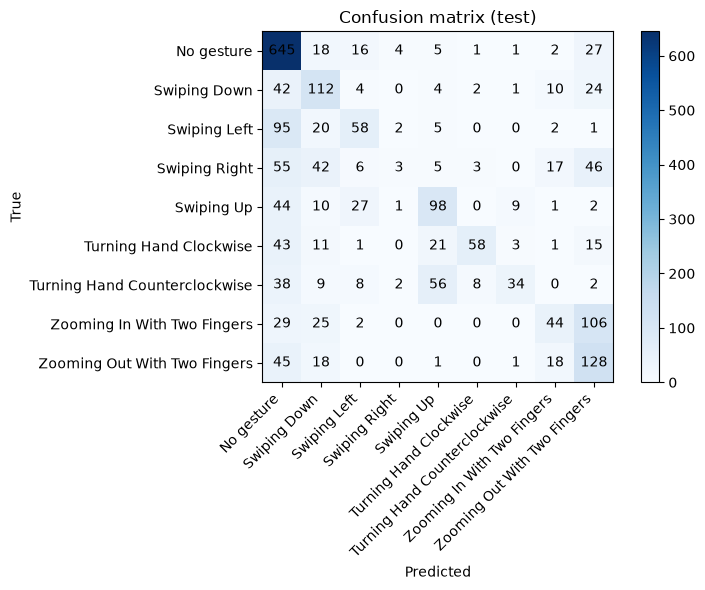

In [6]:
test_loss, test_acc = run_epoch(test_loader, model, criterion)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        logits = model(sequences)
        y_pred.extend(logits.argmax(dim=1).cpu().numpy())
        y_true.extend(labels.numpy())

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=LABELS,
        digits=4,
    )
)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES), LABELS, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES), LABELS)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test)")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## DATA 2 (9 classes)